In [10]:
import matplotlib.pyplot as plt
import numpy as np

from utils.fit_data import ResonanceFitData
from utils.pendulums_data import PendulumsData, prepare_data
from utils.plotting import add_resonance_plot_labels, plot_all, plot_each, save_plot

In [11]:
# single_pendulum = PendulumsData(
#     cols=["mass A"],
#     labels=["100cm"],
#     lengths=np.array([1.0]),
#     data=pd.read_csv("../data/session-5/one-pendulum.csv").dropna(),
# )

In [12]:
cols = ["mass A", "mass B", "mass C", "mass D"]
labels = ["97cm", "99cm", "99.5cm", "100cm"]
lengths = np.array([0.97, 0.99, 0.995, 1.0])

In [13]:
small_paper = PendulumsData(
    cols=cols,
    labels=labels,
    lengths=lengths,
    data=prepare_data("../data/session-5/small-sail.csv", cols),
)
small_paper.preprocess_offsets()
small_paper.normalize()
# small_paper.drop_cols(['mass A', 'mass B'])

In [14]:
medium_paper = PendulumsData(
    cols=cols,
    labels=labels,
    lengths=lengths,
    data=prepare_data("../data/session-5/medium-sail.csv", cols),
)
medium_paper.preprocess_offsets()
medium_paper.normalize()
# medium_paper.detrend()

## Small cardboard damping, 3x3 cm

Small Paper Resonance Fit Results:
97cm: peaks=34; mean=0.538
99cm: peaks=13; mean=0.530
99.5cm: peaks=15; mean=0.634
100cm: peaks=20; mean=0.628
Gamma: 0.1409 ± 0.0466


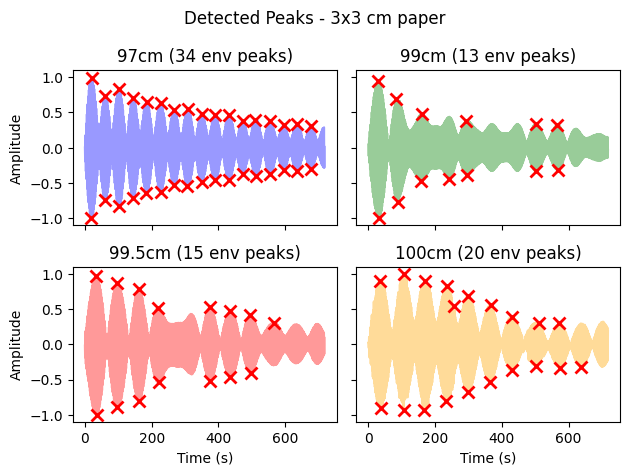

In [15]:
small_paper_resonance = ResonanceFitData(1.0, small_paper)
small_paper_resonance.fit()

# print fit results
print("Small Paper Resonance Fit Results:")
print(small_paper_resonance.envelope_data)
gamma, gamma_err = small_paper_resonance.gamma, small_paper_resonance.gamma_err
print(f"Gamma: {gamma:.4f} ± {gamma_err:.4f}")

# detected peaks plot
small_paper_resonance.plot_detected_peaks(title="Detected Peaks - 3x3 cm paper")
save_plot("session-5/detected-peaks-small-paper.pdf")
plt.show()

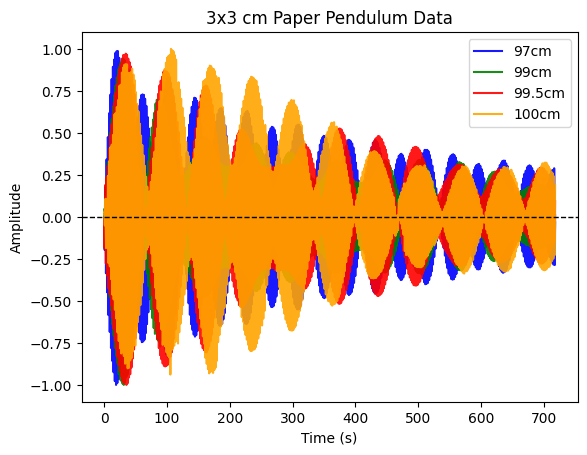

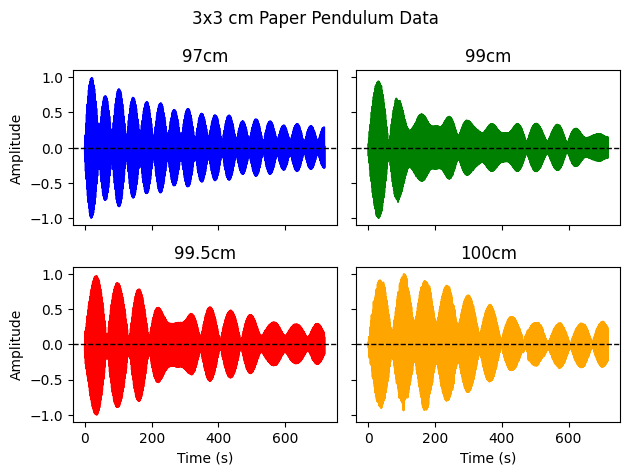

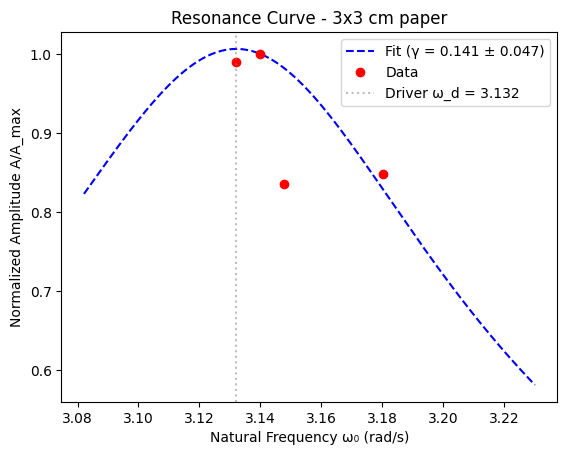

In [16]:
# base plots
plot_all(small_paper, title="3x3 cm Paper Pendulum Data")
save_plot("session-5/amp-vs-time-small-paper-all.pdf")
plt.show()

plot_each(small_paper, title="3x3 cm Paper Pendulum Data")
save_plot("session-5/amp-vs-time-small-paper-each.pdf")
plt.show()

# resonance curve plot
small_paper_resonance.plot_resonance_curve("red", "blue")
add_resonance_plot_labels(title="Resonance Curve - 3x3 cm paper")
save_plot("session-5/resonance-curve-small-paper.pdf")
plt.show()

## Medium cardboard damping, 5x5 cm

Medium Paper Resonance Fit Results:
97cm: peaks=31; mean=0.547
99cm: peaks=10; mean=0.543
99.5cm: peaks=15; mean=0.548
100cm: peaks=12; mean=0.698
Gamma: 0.1028 ± 0.0462


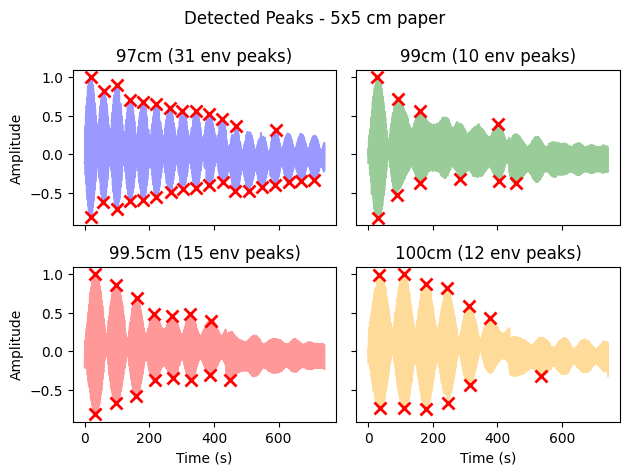

In [17]:
medium_paper_resonance = ResonanceFitData(1.0, medium_paper)
medium_paper_resonance.fit()

# fit results
print("Medium Paper Resonance Fit Results:")
print(medium_paper_resonance.envelope_data)
gamma, gamma_err = medium_paper_resonance.gamma, medium_paper_resonance.gamma_err
print(f"Gamma: {gamma:.4f} ± {gamma_err:.4f}")

# detected peaks plot
medium_paper_resonance.plot_detected_peaks(title="Detected Peaks - 5x5 cm paper")
save_plot("session-5/detected-peaks-medium-paper.pdf")
plt.show()

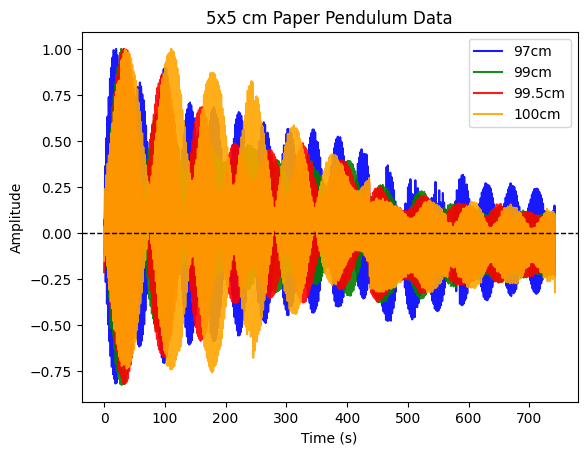

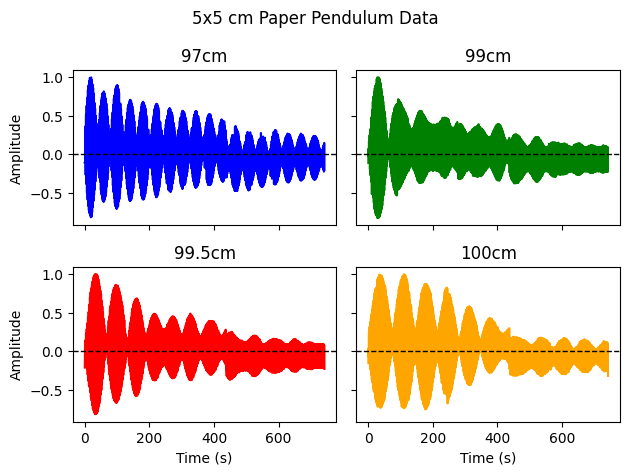

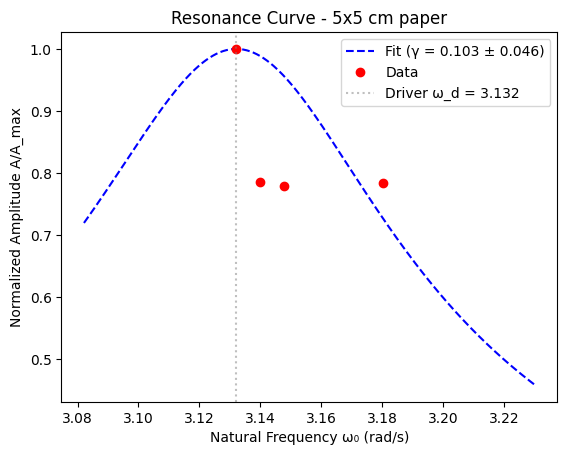

In [18]:
# base plots
plot_all(medium_paper, title="5x5 cm Paper Pendulum Data")
save_plot("session-5/amp-vs-time-medium-paper-all.pdf")
plt.show()

plot_each(medium_paper, title="5x5 cm Paper Pendulum Data")
save_plot("session-5/amp-vs-time-medium-paper-each.pdf")
plt.show()

# resonance curve plot
medium_paper_resonance.plot_resonance_curve("red", "blue")
add_resonance_plot_labels("Resonance Curve - 5x5 cm paper")
save_plot("session-5/resonance-curve-medium-paper.pdf")
plt.show()